# Machine Learning Engineer Nanodegree
## Model Evaluation & Validation
## Project: Predicting Boston Housing Prices

Welcome to the first project of the Machine Learning Engineer
### first project 
* 
read the housing dataset and show the first 5 linef 

In [55]:
# Import libraries necessary for this project
import numpy as np
import pandas as pd
import visuals as vs # Supplementary code
from sklearn.model_selection import ShuffleSplit

#### read the data saved on the same location and display it 

In [56]:
# Pretty display for notebooks
%matplotlib inline

# Load the Boston housing dataset
data = pd.read_csv(r'D:\Depi R5\Projects repo\ML\ML_P1\data\housing.csv')

data.head()

,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0


* gathering all information about dataset
* 1- type of all data
* shape of the data
* read the statistics of this data
* read the statistic of the MEDV feature and see if they are any outliers or missing values

In [57]:
# Type of all data
type_of_data = data.dtypes
print("Type of all data:")
print(type_of_data)

# Print the shape of the data
print("\nShape of the data:")
print(data.shape)

# Display the basic statistics
print("\nBasic statistics:")
print(data.describe())

# Display statistics of the prediction column
print("\nStatistics of the prediction column (MEDV):")
print(data['MEDV'].describe())

Type of all data:
RM         float64
LSTAT      float64
PTRATIO    float64
MEDV       float64
dtype: object

Shape of the data:
(489, 4)

Basic statistics:
               RM       LSTAT     PTRATIO          MEDV
count  489.000000  489.000000  489.000000  4.890000e+02
mean     6.240288   12.939632   18.516564  4.543429e+05
std      0.643650    7.081990    2.111268  1.653403e+05
min      3.561000    1.980000   12.600000  1.050000e+05
25%      5.880000    7.370000   17.400000  3.507000e+05
50%      6.185000   11.690000   19.100000  4.389000e+05
75%      6.575000   17.120000   20.200000  5.187000e+05
max      8.398000   37.970000   22.000000  1.024800e+06

Statistics of the prediction column (MEDV):
count    4.890000e+02
mean     4.543429e+05
std      1.653403e+05
min      1.050000e+05
25%      3.507000e+05
50%      4.389000e+05
75%      5.187000e+05
max      1.024800e+06
Name: MEDV, dtype: float64


* on the code below i assign new var for the prediction column and drop it from original dataset
* i assigne the prediction column as a price and other column as a features data

In [58]:
prices = data['MEDV']
features = data.drop('MEDV', axis=1)

# Print the shape of the data
print('Boston housing dataset has {0} data points with {1} variables each.'.format(*data.shape))

Boston housing dataset has 489 data points with 4 variables each.


## Data Exploration
In this first section of this project, you will make a cursory investigation about the Boston housing data and provide your observations. Familiarizing yourself with the data through an explorative process is a fundamental practice to help you better understand and justify your results.

Since the main goal of this project is to construct a working model which has the capability of predicting the value of houses, we will need to separate the dataset into **features** and the **target variable**. 
* The **features**, `'RM'`, `'LSTAT'`, and `'PTRATIO'`, give us quantitative information about each data point.
*  The **target variable**, `'MEDV'`, will be the variable we seek to predict. These are stored in `features` and `prices`, respectively.

### Implementation: Calculate Statistics
***
***


* claculate the statistics for the code below
* get the minimum  and the max of the price data
* get the mean
* get the median
* get the mode
* calculate the std
- need to print the data 

In [59]:
# Calculate statistics for the target prices
from numpy import mean, median, std

minimum_price = min(prices)
maximum_price = max(prices)
mean_price = mean(prices)
median_price = median(prices)
std_price = std(prices)

# Display the calculated statistics
print("Statistics for Boston housing dataset:\n")
print("Minimum price: ${:,.2f}".format(minimum_price))
print("Maximum price: ${:,.2f}".format(maximum_price))
print("Mean price: ${:,.2f}".format(mean_price))
print("Median price: ${:,.2f}".format(median_price))
print("Standard deviation of prices: ${:,.2f}".format(std_price))

Statistics for Boston housing dataset:

Minimum price: $105,000.00
Maximum price: $1,024,800.00
Mean price: $454,342.94
Median price: $438,900.00
Standard deviation of prices: $165,171.13


### Question 1 - Feature Observation
As a reminder, we are using three features from the Boston housing dataset: `'RM'`, `'LSTAT'`, and `'PTRATIO'`. For each data point (neighborhood):
- `'RM'` is the average number of rooms among homes in the neighborhood.
- `'LSTAT'` is the percentage of homeowners in the neighborhood considered "lower class" (working poor).
- `'PTRATIO'` is the ratio of students to teachers in primary and secondary schools in the neighborhood.


** Using your intuition, for each of the three features above, do you think that an increase in the value of that feature would lead to an **increase** in the value of `'MEDV'` or a **decrease** in the value of `'MEDV'`? Justify your answer for each.**



**Hint:** This problem can phrased using examples like below.  


* Would you expect a home that has an `'RM'` value(number of rooms) of 6 be worth more or less than a home that has an `'RM'` value of 7?


1. **RM (average number of rooms):**
   An increase in `RM` is expected to increase `MEDV`. A house with 7 rooms would generally be worth more than a house with 6 rooms because it provides more living space.

* Would you expect a neighborhood that has an `'LSTAT'` value(percent of lower class workers) of 15 have home prices be worth more or less than a neighborhood that has an `'LSTAT'` value of 20?


2. **LSTAT (percentage of lower-status population):**
   An increase in `LSTAT` is expected to decrease `MEDV`. A neighborhood with an `LSTAT` value of 15% would generally have higher house prices than a neighborhood with an `LSTAT` value of 20%.

* Would you expect a neighborhood that has an `'PTRATIO'` value(ratio of students to teachers) of 10 have home prices be worth more or less than a neighborhood that has an `'PTRATIO'` value of 15?

3. **PTRATIO (student-to-teacher ratio):**
   An increase in `PTRATIO` is expected to decrease `MEDV`. A lower ratio, such as 10 students per teacher, may indicate better schools than a ratio of 15, making the neighborhood more desirable and increasing house prices.

**Conclusion:** `RM` has a positive relationship with house prices, while `LSTAT` and `PTRATIO` generally have negative relationships with house prices.

********************************

----

## Developing a Model
In this second section of the project, you will develop the tools and techniques necessary for a model to make a prediction. Being able to make accurate evaluations of each model's performance through the use of these tools and techniques helps to greatly reinforce the confidence in your predictions.

## takecare for this part to focus for every stage

*****************************
**************************

*****************************************
********************************************

## R2 Score

### Implementation: Define a Performance Metric
- It is difficult to measure the quality of a given model without quantifying its performance over training and testing.
- This is typically done using some type of performance metric, whether it is through calculating some type of error, the goodness of fit, or some other useful measurement.
-  For this project, you will be calculating the [*coefficient of determination*](http://stattrek.com/statistics/dictionary.aspx?definition=coefficient_of_determination), R<sup>2</sup>, to quantify your model's performance.
-  The coefficient of determination for a model is a useful statistic in regression analysis, as it often describes how "good" that model is at making predictions. 
******************************************


The values for R<sup>2</sup> range from 0 to 1, which captures the percentage of squared correlation between the predicted and actual values of the **target variable**. 
************************************
A model with an R<sup>2</sup> of 0 is no better than a model that always predicts the *mean* of the target variable, whereas a model with an R<sup>2</sup> of 1 perfectly predicts the target variable. 

Any value between 0 and 1 indicates what percentage of the target variable, using this model, can be explained by the **features**. _A model can be given a negative R<sup>2</sup> as well, which indicates that the model is **arbitrarily worse** than one that always predicts the mean of the target variable.

******************************************
For the `performance_metric` function in the code cell below, you will need to implement the following:
- Use `r2_score` from `sklearn.metrics` to perform a performance calculation between `y_true` and `y_predict`.
- Assign the performance score to the `score` variable.

In [60]:
# Implement the R2 performance metric.
from sklearn.metrics import r2_score


def performance_metric(y_true, y_predict):
    """Calculate the coefficient of determination between actual and predicted values."""
    score = r2_score(y_true, y_predict)
    return score

### Question 2 - Goodness of Fit
Assume that a dataset contains five data points and a model made the following predictions for the target variable:

| True Value | Prediction |
| :-------------: | :--------: |
| 3.0 | 2.5 |
| -0.5 | 0.0 |
| 2.0 | 2.1 |
| 7.0 | 7.8 |
| 4.2 | 5.3 |

Run the code cell below to use the `performance_metric` function and calculate this model's coefficient of determination.

In [61]:
# Calculate the coefficient of determination for the example model.
y_true = [3, -0.5, 2, 7, 4.2]
y_predict = [2.5, 0.0, 2.1, 7.8, 5.3]

score = performance_metric(y_true, y_predict)
print("Model has a coefficient of determination, R2, of {:.3f}.".format(score))

Model has a coefficient of determination, R2, of 0.923.


* Would you consider this model to have successfully captured the variation of the target variable? 
* Why or why not?

** Hint: **  The R2 score is the proportion of the variance in the dependent variable that is predictable from the independent variable. In other words:
* R2 score of 0 means that the dependent variable cannot be predicted from the independent variable.
* R2 score of 1 means the dependent variable can be predicted from the independent variable.
* R2 score between 0 and 1 indicates the extent to which the dependent variable is predictable. An 
* R2 score of 0.40 means that 40 percent of the variance in Y is predictable from X.

### Answer:

The model has an R2 score of approximately **0.923**.

This means that the model explains about **92.3% of the variation** in the target values using the available features. The remaining **7.7%** is not explained by this model and may be caused by other factors or prediction errors.

Therefore, the model has successfully captured most of the variation in the target variable. However, an R2 score of 0.923 does **not** mean that every prediction is 92.3% accurate. It measures how well the model explains the overall variation compared with simply predicting the average target value.

### Implementation: Shuffle and Split Data

The dataset should be shuffled and split into training and testing subsets. Use an 80/20 split and keep the test set unseen during model training.

For the code cell below:

- Import `train_test_split` from `sklearn.model_selection`.
- Split `features` and `prices` into `X_train`, `X_test`, `y_train`, and `y_test`.
- Set a fixed `random_state` so the results are reproducible.

In [62]:
# Shuffle and split the features and prices into training and testing subsets.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    prices,
    test_size=0.2,
    random_state=42
)

print("Training and testing split was successful.")
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training and testing split was successful.
Training set: (391, 3)
Testing set: (98, 3)


### Question 3 - Training and Testing

* What is the benefit to splitting a dataset into some ratio of training and testing subsets for a learning algorithm?

**Hint:** Think about how overfitting or underfitting is contingent upon how splits on data is done.

### Answer:

Splitting the dataset into training and testing subsets allows the model to learn from one part of the data and be evaluated on separate, unseen data. The training set is used to learn the relationship between the features and the house prices, while the testing set measures how well the model generalizes to new examples.

This separation helps detect overfitting. A model may achieve a high score on the training data by memorizing its patterns, but a much lower score on the testing data indicates poor generalization. Using a test set that is not used during training gives a more reliable estimate of the model's real-world performance.

----

## Analyzing Model Performance
In this third section of the project, you'll take a look at several models' learning and testing performances on various subsets of training data. Additionally, you'll investigate one particular algorithm with an increasing `'max_depth'` parameter on the full training set to observe how model complexity affects performance. Graphing your model's performance based on varying criteria can be beneficial in the analysis process, such as visualizing behavior that may not have been apparent from the results alone.

### Learning Curves
The following code cell produces four graphs for a decision tree model with different maximum depths. Each graph visualizes the learning curves of the model for both training and testing as the size of the training set is increased. Note that the shaded region of a learning curve denotes the uncertainty of that curve (measured as the standard deviation). The model is scored on both the training and testing sets using R<sup>2</sup>, the coefficient of determination.  

Run the code cell below and use these graphs to answer the following question.

In [63]:
# Create learning curves for decision tree models with different depths.
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve, ShuffleSplit
from sklearn.tree import DecisionTreeRegressor


def ModelLearning(X, y):
    """Plot training and validation scores for different tree depths."""
    cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)
    train_sizes = np.linspace(0.1, 1.0, 8)
    depths = [1, 3, 6, 10]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    for axis, depth in zip(axes.ravel(), depths):
        model = DecisionTreeRegressor(max_depth=depth, random_state=0)
        sizes, train_scores, validation_scores = learning_curve(
            model,
            X,
            y,
            cv=cv,
            train_sizes=train_sizes,
            scoring="r2"
        )

        train_mean = np.mean(train_scores, axis=1)
        validation_mean = np.mean(validation_scores, axis=1)

        axis.plot(sizes, train_mean, "o-", label="Training score")
        axis.plot(sizes, validation_mean, "o-", label="Validation score")
        axis.set_title("Decision Tree max_depth = {}".format(depth))
        axis.set_xlabel("Number of training examples")
        axis.set_ylabel("R2 score")
        axis.set_ylim(-0.05, 1.05)
        axis.legend(loc="lower right")
        axis.grid(alpha=0.3)

    fig.suptitle("Decision Tree Learning Curves")
    fig.tight_layout()
    plt.show()

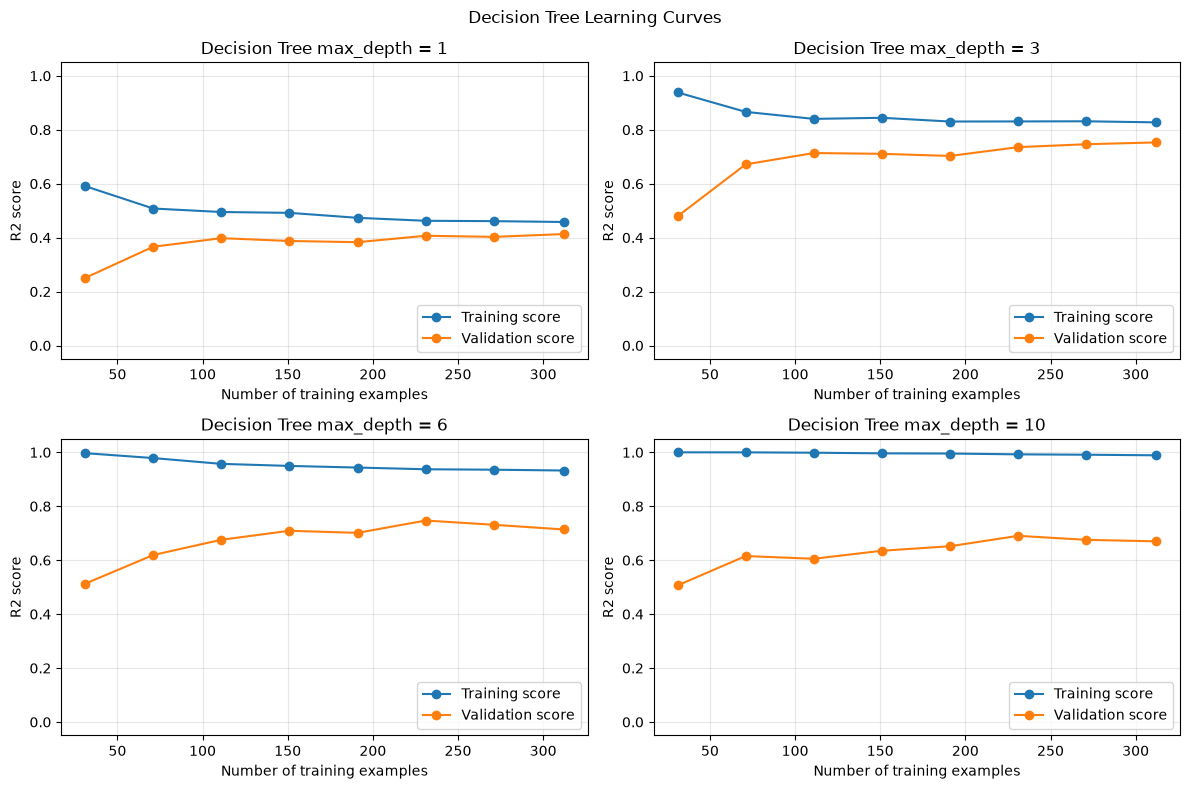

In [64]:
# Run the learning-curve analysis on the training data.
ModelLearning(X_train, y_train)

### Question 4 - Learning the Data
* Choose one of the graphs above and state the maximum depth for the model.
* What happens to the score of the training curve as more training points are added? What about the validation curve?
* Would having more training points benefit the model?

**Hint:** Are the learning curves converging to particular scores? Generally speaking, the more data you have, the better. But if your training and validation curves are converging with a score above your benchmark threshold, would this be necessary?
Think about the pros and cons of adding more training points based on whether the curves are converging.

### Answer:

For the model with `max_depth = 3`, the training score is high when the training set is small and gradually decreases as more training examples are added. The validation score generally increases as more examples are added and then begins to stabilize.

This shows that additional training data can improve the model's ability to generalize, especially when the validation score is still increasing. However, once the training and validation curves converge, adding much more data may provide only a limited improvement.

### Complexity Curves
The following code cell produces a graph for a decision tree model that has been trained and validated on the training data using different maximum depths. The graph produces two complexity curves — one for training and one for validation. Similar to the **learning curves**, the shaded regions of both the complexity curves denote the uncertainty in those curves, and the model is scored on both the training and validation sets using the `performance_metric` function.  

** Run the code cell below and use this graph to answer the following two questions Q5 and Q6. **

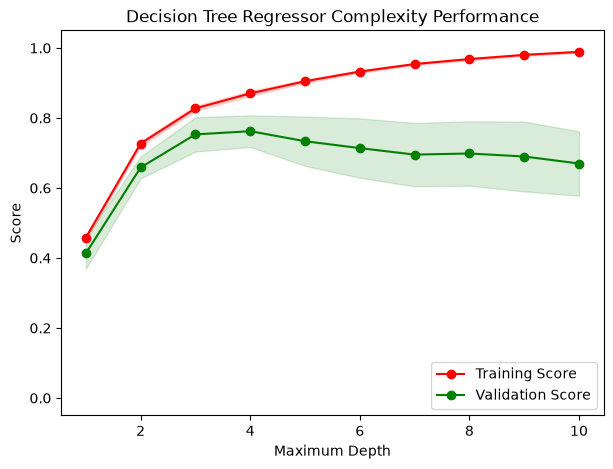

In [65]:
# Run the model-complexity analysis once on the training data.
vs.ModelComplexity(X_train, y_train)

### Question 5 - Bias-Variance Tradeoff
* When the model is trained with a maximum depth of 1, does the model suffer from high bias or from high variance? 
* How about when the model is trained with a maximum depth of 10? What visual cues in the graph justify your conclusions?

**Hint:** High bias is a sign of underfitting(model is not complex enough to pick up the nuances in the data) and high variance is a sign of overfitting(model is by-hearting the data and cannot generalize well). Think about which model(depth 1 or 10) aligns with which part of the tradeoff.

### Answer:

At `max_depth = 1`, the decision tree has **high bias** because it is too simple to learn the patterns in the data. This is underfitting, so both the training and validation scores are relatively low.

At `max_depth = 10`, the tree has **high variance** because it is complex enough to fit the training data very closely. The training score is much higher than the validation score, which indicates overfitting and weak generalization.

### Question 6 - Best-Guess Optimal Model
* Which maximum depth do you think results in a model that best generalizes to unseen data? 
* What intuition lead you to this answer?

** Hint: ** Look at the graph above Question 5 and see where the validation scores lie for the various depths that have been assigned to the model. Does it get better with increased depth? At what point do we get our best validation score without overcomplicating our model? And remember, Occams Razor states "Among competing hypotheses, the one with the fewest assumptions should be selected."

### Answer:

The best-guess optimal model uses `max_depth = 4`. In the validation-curve analysis, this depth achieved the highest average validation R2 score, approximately **0.762**.

This depth provides a good balance between model complexity and generalization. Smaller depths underfit the data, while larger depths begin to overfit and their validation scores decrease.

-----

## Evaluating Model Performance
In this final section of the project, you will construct a model and make a prediction on the client's feature set using an optimized model from `fit_model`.

### Question 7 - Cross-Validation

* What is the k-fold cross-validation training technique? 

* What benefit does this technique provide for grid search when optimizing a model?

**Hint:** When explaining the k-fold cross validation technique, be sure to touch upon what 'k' is, how the dataset is split into different parts for training and testing and the number of times it is run based on the 'k' value.

When thinking about how k-fold cross validation helps grid search, think about the main drawbacks of grid search which are hinged upon **using a particular subset of data for training or testing** and how k-fold cv could help alleviate that. You can refer to the [docs](http://scikit-learn.org/stable/modules/cross_validation.html#cross-validation) for your answer.

### Answer:

In k-fold cross-validation, the training data is divided into `k` approximately equal parts called folds. The model is trained `k` times. During each run, one fold is used for validation and the remaining `k - 1` folds are used for training. The final performance is calculated by averaging the scores from all runs.

Cross-validation makes grid search more reliable because every candidate parameter combination is evaluated on several different validation subsets instead of only one split. This reduces the effect of a lucky or unlucky split and helps select hyperparameters that generalize better to unseen data.

### Implementation: Fitting and Optimizing the Final Model

The final model uses a **Random Forest Regressor**, an ensemble of decision trees. Random Forest can model nonlinear relationships and is usually more stable than a single decision tree.

The code below uses `GridSearchCV` with 5-fold cross-validation to search for the best values of:

- `n_estimators`: the number of trees in the forest.
- `max_depth`: the maximum depth of each tree.

The model is selected using negative mean squared error. After fitting, the best model is evaluated on the unseen test set using R2, MAE, and RMSE.

In [66]:
# Define and optimize a Random Forest regressor.
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV

rf = RandomForestRegressor(random_state=0)
cv = KFold(n_splits=5, shuffle=True, random_state=0)
scoring = "neg_mean_squared_error"
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7, 10]
}

grid_search = GridSearchCV(rf, param_grid, cv=cv, scoring=scoring)
optimized_model = grid_search.fit(X_train, y_train)

### Question 9 - Optimal Model

* What maximum depth and number of estimators does the optimized Random Forest model have?
* How does the selected depth compare to your guess in Question 6?

Run the code block below to evaluate the optimized model on the unseen test data.

In [67]:
# Evaluate the optimized model on the unseen test data.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_model = optimized_model.best_estimator_
y_test_pred = best_model.predict(X_test)

print("Best parameters:", optimized_model.best_params_)
print("Test R2: {:.3f}".format(r2_score(y_test, y_test_pred)))
print("Test MAE: ${:,.2f}".format(mean_absolute_error(y_test, y_test_pred)))
print("Test RMSE: ${:,.2f}".format(np.sqrt(mean_squared_error(y_test, y_test_pred))))

Best parameters: {'max_depth': 5, 'n_estimators': 50}
Test R2: 0.860
Test MAE: $42,859.94
Test RMSE: $55,500.88


**Answer:**

The optimized Random Forest model has the following parameters:

- `max_depth = 5`
- `n_estimators = 50`

On the unseen test set, the model achieved:

- `R2 = 0.860`
- `MAE = $42,859.94`
- `RMSE = $55,500.88`

The R2 score means that the final model explains approximately **86.0% of the variation** in house prices. The model generalizes reasonably well because it was evaluated on data that was not used during training.

### Question 10 - Predicting Selling Prices
Imagine that you were a real estate agent in the Boston area looking to use this model to help price homes owned by your clients that they wish to sell. You have collected the following information from three of your clients:

| Feature | Client 1 | Client 2 | Client 3 |
| :---: | :---: | :---: | :---: |
| Total number of rooms in home | 5 rooms | 4 rooms | 8 rooms |
| Neighborhood poverty level (as %) | 17% | 32% | 3% |
| Student-teacher ratio of nearby schools | 15-to-1 | 22-to-1 | 12-to-1 |

* What price would you recommend each client sell his/her home at? 
* Do these prices seem reasonable given the values for the respective features? 

**Hint:** Use the statistics you calculated in the **Data Exploration** section to help justify your response.  Of the three clients, client 3 has has the biggest house, in the best public school neighborhood with the lowest poverty level; while client 2 has the smallest house, in a neighborhood with a relatively high poverty rate and not the best public schools.

Run the code block below to have your optimized model make predictions for each client's home.

In [68]:
# Predict the selling prices for the three clients.
client_data = pd.DataFrame(
    [
        [5, 17, 15],  # Client 1
        [4, 32, 22],  # Client 2
        [8, 3, 12]    # Client 3
    ],
    columns=features.columns
)

predicted_prices = best_model.predict(client_data)
for i, price in enumerate(predicted_prices):
    print("Predicted selling price for Client {}'s home: ${:,.2f}".format(i + 1, price))

Predicted selling price for Client 1's home: $410,563.34
Predicted selling price for Client 2's home: $244,186.79
Predicted selling price for Client 3's home: $898,194.58


### Answer:

The predicted selling prices are:

- **Client 1:** $410,563.34
- **Client 2:** $244,186.79
- **Client 3:** $898,194.58

These predictions are reasonable relative to the clients' features. Client 3 is predicted to have the highest price because the home has the largest number of rooms, the lowest `LSTAT` value, and the lowest `PTRATIO`. Client 2 is predicted to have the lowest price because it has fewer rooms, a higher `LSTAT` value, and a higher student-to-teacher ratio. Client 1 falls between the other two clients in terms of both features and predicted price.